# House Price Prediction
**Author Name** : [Baqar Ali](https://www.linkedin.com/in/baqar-ali-0858b0374?utm_source=share_via&utm_content=profile&utm_medium=member_android)\
**Date** : 23-june-2026\
**Dataset**: [House price prediction](https://www.kaggle.com/datasets/shree1992/housedata)
![House Price Prediction Logo](logo.jpeg)\
**Note:** This model is trained on a Washington State, USA housing dataset.
Predictions are applicable to the US real estate market only.

## Problem Statement:
Estimating the accurate price of a house is a major challenge for both buyers and
sellers. Manual estimation is often unreliable, time-consuming, and influenced by
bias. This project builds a machine learning regression model trained on real
Washington State housing data to predict house prices based on property features
such as size, location, number of bedrooms, bathrooms, and condition.

## Objectives:
The main objective of this project is to build a simple and user-friendly system that can predict house prices accurately using machine learning techniques. The system aims to:

- Predict house prices accurately based on property features
- Reduce dependency on manual or biased price estimation
- Compare multiple ML models and select the best performer
- Deploy a simple and reliable prediction system for end users

In [43]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split,GridSearchCV

# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")

# metrics
from sklearn.metrics import r2_score,mean_absolute_error, mean_squared_error
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [44]:
df = pd.read_csv("data.csv")
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   str    
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   str    
 15  city           4600 non-null   str    
 16  statezip       4600 non-null   str    
 17  country        4600 non-null   str    
dtypes: float64(4), int6

In [46]:
df=df.drop("date",axis=1)

In [47]:
df.isnull().sum()

price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

In [48]:
df = df.drop_duplicates()

## Relationship of every column with target

<Axes: xlabel='bedrooms', ylabel='price'>

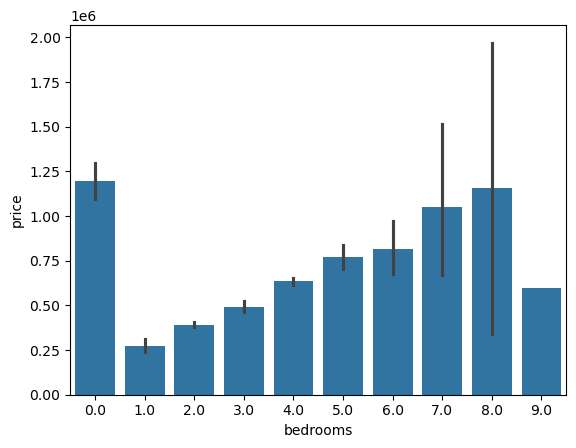

In [49]:
df["bedrooms"].value_counts()
sns.barplot(x=df["bedrooms"],y=df["price"])

In [50]:
df[df["bedrooms"]==0]

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
2365,1095000.0,0.0,0.0,3064,4764,3.5,0,2,3,3064,0,1990,2009,814 E Howe St,Seattle,WA 98102,USA
3209,1295648.0,0.0,0.0,4810,28008,2.0,0,0,3,4810,0,1990,2009,20418 NE 64th Pl,Redmond,WA 98053,USA


In [51]:
df = df[(df["bedrooms"] != 0) & (df["bathrooms"] != 0)]

<Axes: xlabel='bedrooms', ylabel='price'>

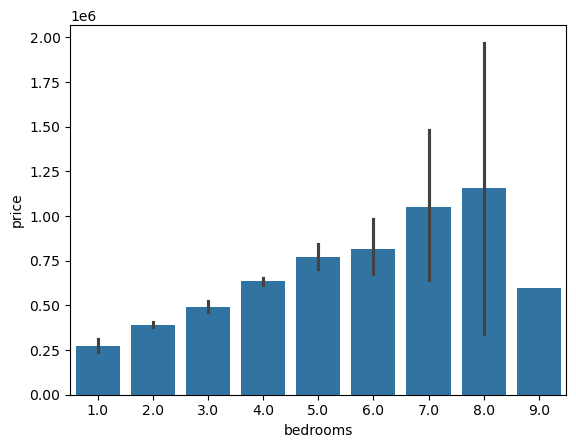

In [52]:
df["bedrooms"].value_counts()
sns.barplot(x=df["bedrooms"],y=df["price"])

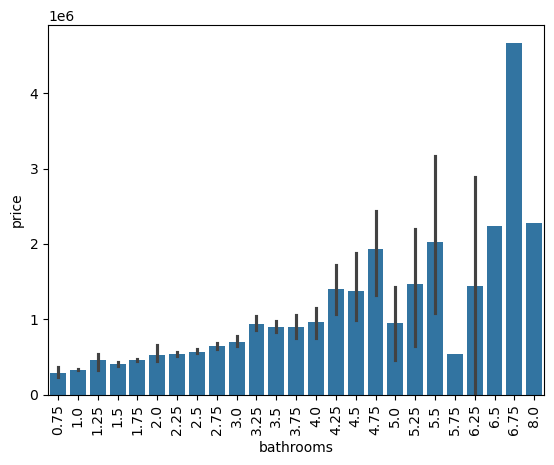

In [53]:
df["bathrooms"].value_counts()
sns.barplot(x=df["bathrooms"],y=df["price"])
plt.xticks(rotation=90)
plt.show()

In [54]:
df.sort_values("price", ascending=False).head(10)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
4350,26590000.0,3.0,2.00,1180,7793,1.0,0,0,4,1180,0,1992,0,12005 SE 219th Ct,Kent,WA 98031,USA
4346,12899000.0,3.0,2.50,2190,11394,1.0,0,0,3,1550,640,1956,2001,5426 40th Ave W,Seattle,WA 98199,USA
2286,7062500.0,5.0,4.50,10040,37325,2.0,1,2,3,7680,2360,1940,2001,4442 95th Ave NE,Bellevue,WA 98004,USA
2654,4668000.0,5.0,6.75,9640,13068,1.0,1,4,3,4820,4820,1983,2009,5044 Butterworth Rd,Mercer Island,WA 98040,USA
2761,4489000.0,4.0,3.00,6430,27517,2.0,0,0,3,6430,0,2001,0,1149-1199 91st Ave NE,Bellevue,WA 98004,USA
3729,3800000.0,5.0,5.50,7050,42840,1.0,0,2,4,4320,2730,1978,2000,1365 91st Ave NE,Clyde Hill,WA 98004,USA
1637,3710000.0,4.0,3.50,5550,28078,2.0,0,2,4,3350,2200,2000,0,3222 78th Pl NE,Medina,WA 98039,USA
252,3200000.0,7.0,4.50,6210,8856,2.5,0,2,5,4760,1450,1910,0,1230 Warren Ave N,Seattle,WA 98109,USA
1567,3100000.0,6.0,4.25,6980,15682,3.0,0,4,4,5330,1650,1999,0,5243 Forest Ave SE,Mercer Island,WA 98040,USA
2772,3000000.0,4.0,4.25,4850,12445,2.0,1,4,5,3850,1000,1989,0,11031 Champagne Point Rd NE,Kirkland,WA 98034,USA


<Axes: xlabel='price', ylabel='Count'>

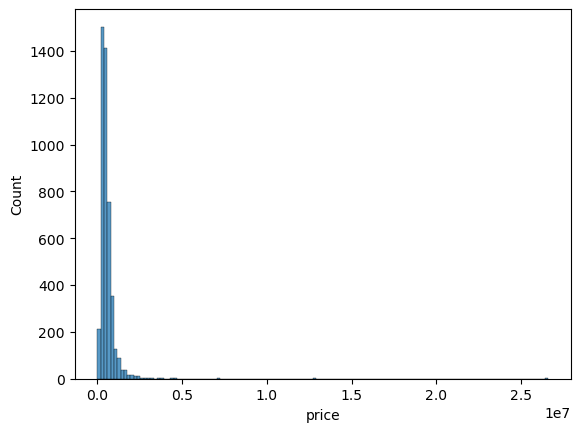

In [55]:
sns.histplot(df["price"])

<Axes: ylabel='price'>

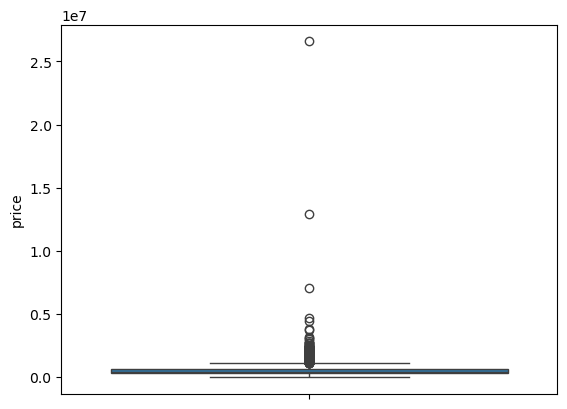

In [56]:
sns.boxplot(df["price"])

In [57]:
df[df["price"] > 1.e7]

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
4346,12899000.0,3.0,2.5,2190,11394,1.0,0,0,3,1550,640,1956,2001,5426 40th Ave W,Seattle,WA 98199,USA
4350,26590000.0,3.0,2.0,1180,7793,1.0,0,0,4,1180,0,1992,0,12005 SE 219th Ct,Kent,WA 98031,USA


In [58]:
df = df[df["price"] <= 3.4e6]

<Axes: ylabel='price'>

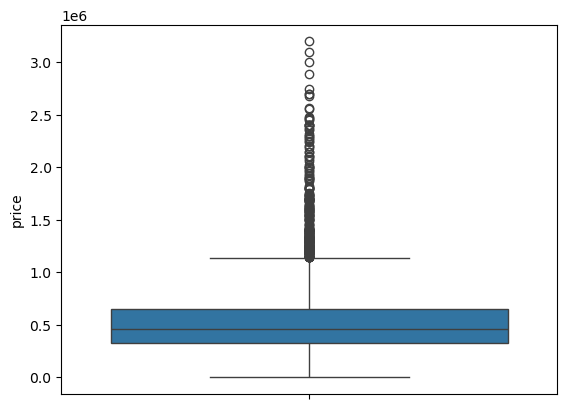

In [59]:
sns.boxplot(df["price"])

In [60]:
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [61]:
df.info()

<class 'pandas.DataFrame'>
Index: 4591 entries, 0 to 4599
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          4591 non-null   float64
 1   bedrooms       4591 non-null   float64
 2   bathrooms      4591 non-null   float64
 3   sqft_living    4591 non-null   int64  
 4   sqft_lot       4591 non-null   int64  
 5   floors         4591 non-null   float64
 6   waterfront     4591 non-null   int64  
 7   view           4591 non-null   int64  
 8   condition      4591 non-null   int64  
 9   sqft_above     4591 non-null   int64  
 10  sqft_basement  4591 non-null   int64  
 11  yr_built       4591 non-null   int64  
 12  yr_renovated   4591 non-null   int64  
 13  street         4591 non-null   str    
 14  city           4591 non-null   str    
 15  statezip       4591 non-null   str    
 16  country        4591 non-null   str    
dtypes: float64(4), int64(9), str(4)
memory usage: 808.2 KB


,sqft_lot,price
sqft_lot,1.000000,0.081664
price,0.081664,1.000000


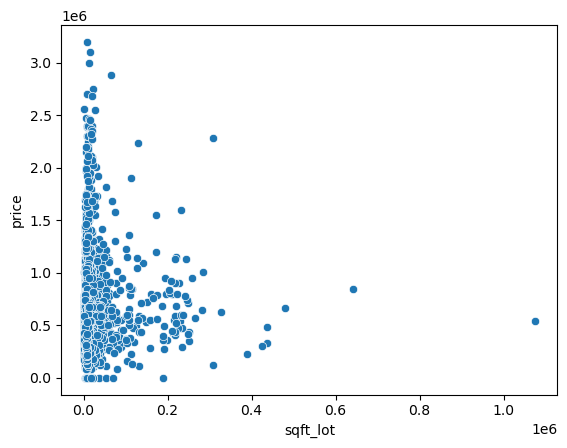

In [62]:
sns.scatterplot(x=df["sqft_lot"],y=df["price"])
df[["sqft_lot","price"]].corr()

,sqft_lot,price
sqft_lot,1.000000,0.081664
price,0.081664,1.000000


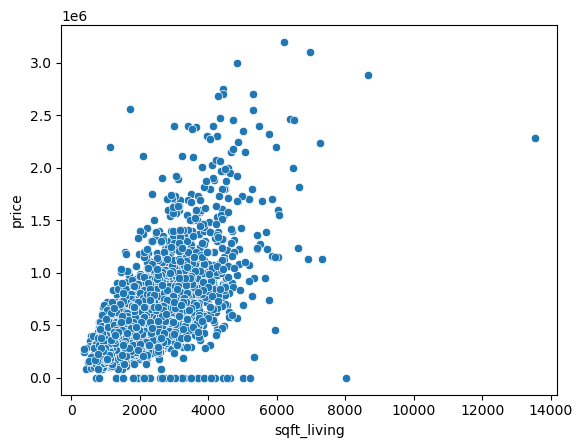

In [63]:
sns.scatterplot(x=df["sqft_living"],y=df["price"])
df[["sqft_lot","price"]].corr()

In [64]:
df["floors"].value_counts()

floors
1.0    2170
2.0    1807
1.5     444
3.0     128
2.5      41
3.5       1
Name: count, dtype: int64

<Axes: xlabel='floors', ylabel='price'>

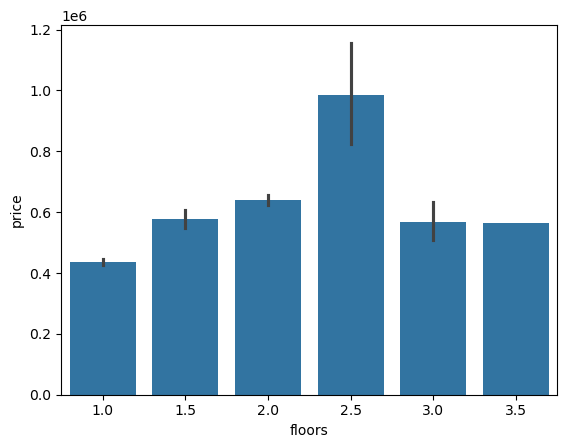

In [65]:
sns.barplot(x=df["floors"],y=df["price"])

In [66]:
df["waterfront"].value_counts()

waterfront
0    4560
1      31
Name: count, dtype: int64

<Axes: xlabel='waterfront', ylabel='price'>

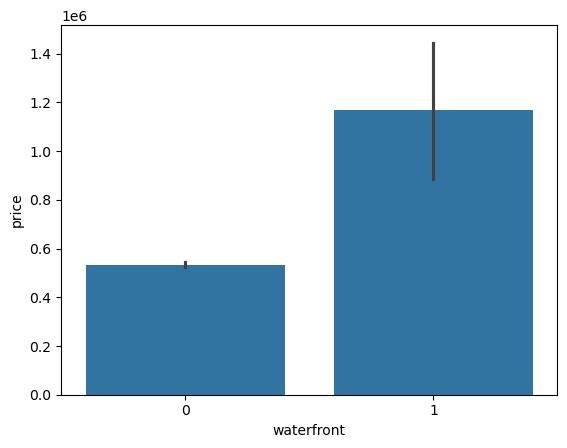

In [67]:
sns.barplot(x=df["waterfront"],y=df["price"])

In [68]:
df.corr(numeric_only=True)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
price,1.000000,0.328003,0.504854,0.656756,0.081664,0.269222,0.151762,0.355895,0.053022,0.567266,0.298072,0.025858,-0.051624
bedrooms,0.328003,1.000000,0.543103,0.604123,0.068538,0.182751,-0.013031,0.109687,0.024302,0.490633,0.332393,0.144075,-0.060539
bathrooms,0.504854,0.543103,1.000000,0.764084,0.107571,0.495662,0.055829,0.205456,-0.121441,0.694062,0.283119,0.468052,-0.219750
sqft_living,0.656756,0.604123,0.764084,1.000000,0.212422,0.351142,0.081155,0.302430,-0.062022,0.875599,0.431708,0.293016,-0.131152
sqft_lot,0.081664,0.068538,0.107571,0.212422,1.000000,0.003737,0.016289,0.073619,0.000524,0.217014,0.033783,0.050697,-0.023024
floors,0.269222,0.182751,0.495662,0.351142,0.003737,1.000000,0.022952,0.030176,-0.274937,0.527007,-0.258385,0.468119,-0.235358
waterfront,0.151762,-0.013031,0.055829,0.081155,0.016289,0.022952,1.000000,0.355414,0.003882,0.055250,0.064557,-0.022602,0.002494
view,0.355895,0.109687,0.205456,0.302430,0.073619,0.030176,0.355414,1.000000,0.063898,0.167726,0.311848,-0.065533,0.020460
condition,0.053022,0.024302,-0.121441,-0.062022,0.000524,-0.274937,0.003882,0.063898,1.000000,-0.178248,0.204669,-0.400282,-0.186292
sqft_above,0.567266,0.490633,0.694062,0.875599,0.217014,0.527007,0.055250,0.167726,-0.178248,1.000000,-0.057705,0.412750,-0.166247


<Axes: xlabel='view', ylabel='price'>

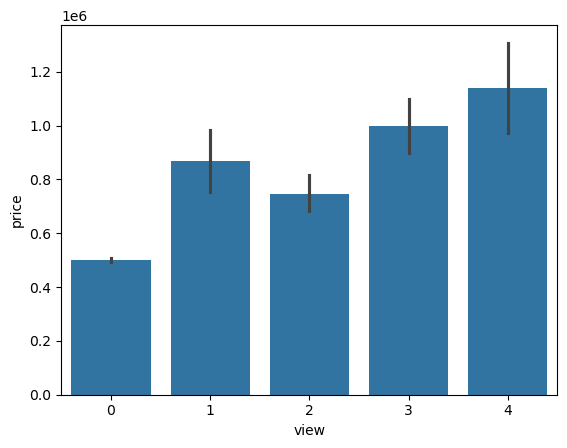

In [69]:
df["view"].value_counts()
sns.barplot(x=df["view"],y=df["price"])

In [70]:
df["condition"].value_counts()

condition
3    2869
4    1249
5     435
2      32
1       6
Name: count, dtype: int64

<Axes: xlabel='condition', ylabel='price'>

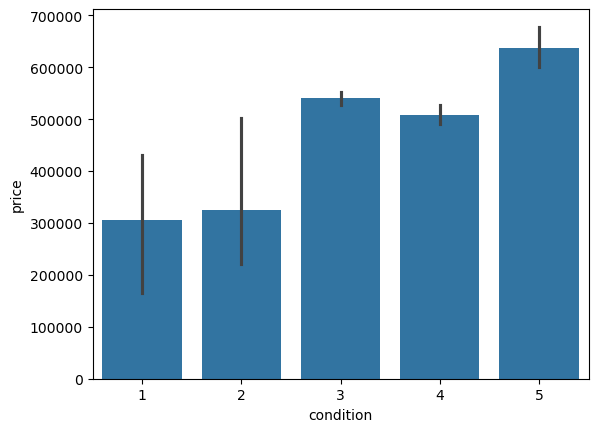

In [71]:
sns.barplot(x=df["condition"],y=df["price"])

<Axes: xlabel='sqft_above', ylabel='price'>

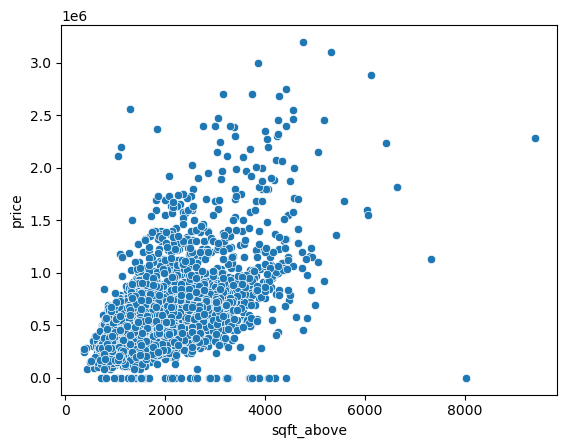

In [72]:
sns.scatterplot(x=df["sqft_above"],y=df["price"])

In [73]:
len(df[df["price"]==0])

49

In [74]:
df = df[df["price"] > 0]


<Axes: xlabel='sqft_basement', ylabel='price'>

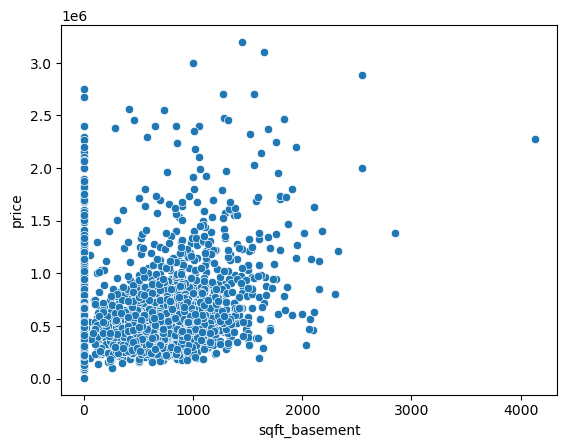

In [75]:
sns.scatterplot(x=df["sqft_basement"],y=df["price"])

<Axes: xlabel='yr_built', ylabel='price'>

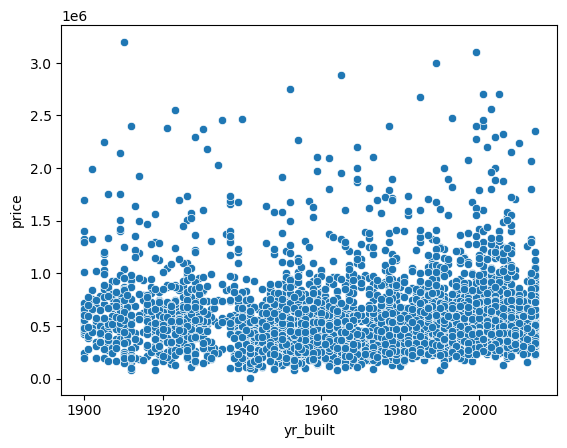

In [76]:
df["yr_built"].value_counts()
sns.scatterplot(x=df["yr_built"],y=df["price"])

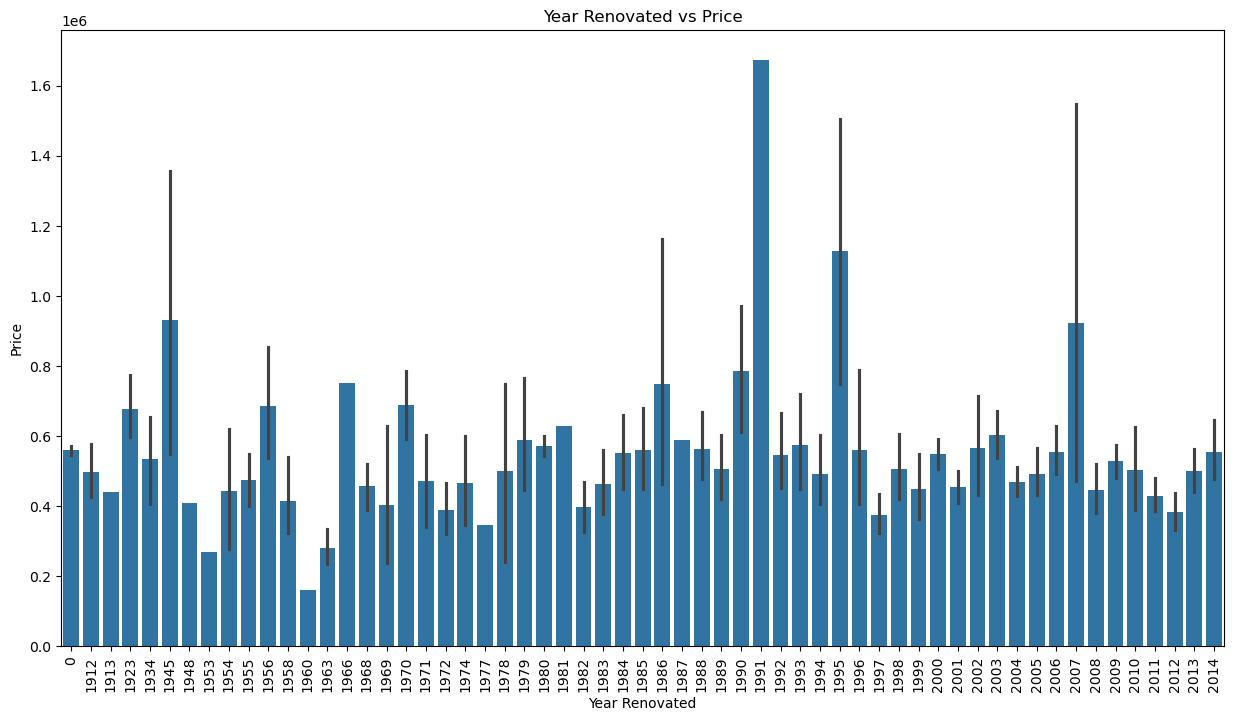

In [77]:
plt.figure(figsize=(15,8))

# barplot
sns.barplot(x="yr_renovated", y="price", data=df)

plt.xticks(rotation=90)
plt.xlabel("Year Renovated")
plt.ylabel("Price")
plt.title("Year Renovated vs Price")

plt.show()

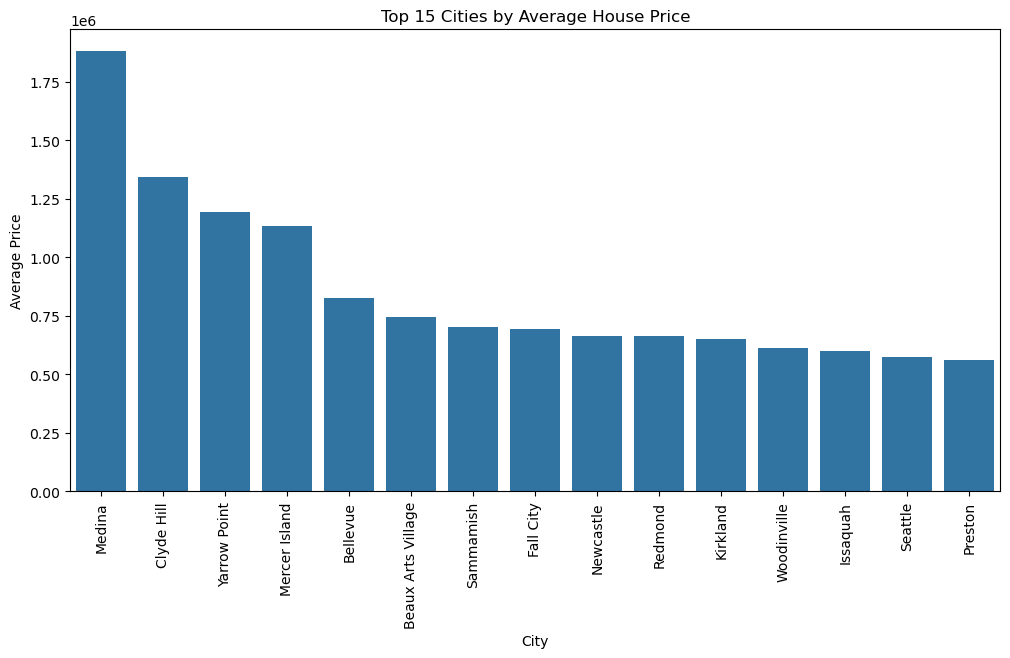

In [78]:
city_price = df.groupby("city")["price"].mean().sort_values(ascending=False)

top_cities = city_price.head(15)

plt.figure(figsize=(12,6))

sns.barplot(x=top_cities.index, y=top_cities.values)

plt.xticks(rotation=90)
plt.xlabel("City")
plt.ylabel("Average Price")
plt.title("Top 15 Cities by Average House Price")

plt.show()


In [79]:
df["city"].nunique()

44

In [80]:
df["statezip"].nunique()

77

### Important Insights

- Checked the relationship of each column with the targeted column
- Some outliers present in the price and be removed from datasets
- 49 houses has price of 0 and these houses be removed from dataset
- useless columns(date and country) was removed from dataset

## Model Training

### Linear Regression(baseline model)

In [81]:
X=df.drop(columns=["price","yr_built","yr_renovated","sqft_lot"])
y=df["price"]

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

cat_cols = X_train.select_dtypes(include=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("cats",
         OneHotEncoder(drop="first", handle_unknown="ignore"),
         cat_cols)
    ],
    remainder="passthrough"
)


model = Pipeline(
    steps=[
        ("preprocessor",preprocessor),
        ("model",LinearRegression())
    ]
)

model.fit(X_train,y_train)

y_pred = model.predict(X_test)

print("R2 score:", r2_score(y_test,y_pred))

R2 score: 0.7601282025868166


### All models

In [82]:
X=df.drop(columns=["price","yr_built","yr_renovated","sqft_lot"])
y = df["price"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
models = {
    "LinearRegression": LinearRegression(),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(random_state=42),
    "SVR": SVR(kernel="rbf"),
    
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42),
}
cat_cols = X_train.select_dtypes(include=["object"]).columns
num_cols = [col for col in X_train.columns if col not in cat_cols]
for name,Model in models.items():
    preprocessor = ColumnTransformer(
        transformers=[
            ("cat",OneHotEncoder(drop="first",handle_unknown="ignore"),cat_cols),
            #("num",StandardScaler(),num_cols)
        ],
        remainder="passthrough"
    )
    model = Pipeline(
        steps=[
            ("preprocessor",preprocessor),
            ("model",Model)
        ]
    )
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    print(f"r2_score of {name} is ",r2_score(y_test,y_pred))
    print(f"mean squared error is of {name} ",mean_squared_error(y_test,y_pred))
    print("---------------------------------------------------")



r2_score of LinearRegression is  0.7601282025868166
mean squared error is of LinearRegression  28134721159.199024
---------------------------------------------------
r2_score of KNN is  0.45710117266286576
mean squared error is of KNN  63676961149.69341
---------------------------------------------------
r2_score of DecisionTree is  0.5076257797566115
mean squared error is of DecisionTree  57750896695.30458
---------------------------------------------------
r2_score of RandomForest is  0.7216596037135079
mean squared error is of RandomForest  32646728466.257854
---------------------------------------------------
r2_score of SVR is  -0.06829252184401091
mean squared error is of SVR  125300733736.39084
---------------------------------------------------
r2_score of GradientBoosting is  0.7593033085559437
mean squared error is of GradientBoosting  28231473523.565228
---------------------------------------------------
r2_score of XGBoost is  0.7645110803497013
mean squared error is of XGB

### XGBoost model

In [83]:
X=df.drop(columns=["price","yr_built","yr_renovated","sqft_lot"])
y = df["price"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# find columns

cat_cols = X_train.select_dtypes(include=["object"]).columns
num_cols = X_train.select_dtypes(exclude=["object"]).columns


# preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols)
    ],
    remainder="passthrough"
)


# pipeline

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBRegressor(random_state=42))
    ]
)


# hyperparameter grid

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 5, 7],
    "model__subsample": [0.8, 1],
    "model__colsample_bytree": [0.8, 1]
}


# Grid Search

xgb_grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)


# train

xgb_grid.fit(X_train, y_train)


# best parameters

print("Best Parameters:")
print(xgb_grid.best_params_)


# prediction

y_pred = xgb_grid.predict(X_test)


# evaluation

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

Best Parameters:
{'model__colsample_bytree': 1, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 300, 'model__subsample': 0.8}
R2 Score: 0.7821018261052166
MAE: 90560.04868441474
MSE: 25557420379.30574


### Gradient boosting model

In [89]:
X=df.drop(columns=["price","yr_built","yr_renovated","sqft_lot"])
y = df["price"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# find columns

cat_cols = X_train.select_dtypes(include=["object"]).columns
num_cols = X_train.select_dtypes(exclude=["object"]).columns


# preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols)
    ]
)


# pipeline

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(random_state=42))
    ]
)


# hyperparameter grid

param_grid = {
    "model__n_estimators": [10, 15, 20, 25],
    "model__max_depth": [2, 4, 6, 15],
    "model__min_samples_split": [2, 8, 12],
    "model__min_samples_leaf": [3, 6, 11]
}


# Grid Search

gb_grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)


# train

gb_grid.fit(X_train, y_train)


# best parameters

print("Best Parameters:")
print(gb_grid.best_params_)


# prediction

y_pred = gb_grid.predict(X_test)



# evaluation

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

Best Parameters:
{'model__max_depth': 15, 'model__min_samples_leaf': 6, 'model__min_samples_split': 2, 'model__n_estimators': 25}
R2 Score: 0.6943278679354314
MAE: 105513.25156007332
MSE: 35852485763.30481


# Dataset Overview

This dataset contains house-related information such as bedrooms, bathrooms, living area,
location, condition, and other property features.

The goal of this project is to build a machine learning regression model that can predict
house prices based on these features.

---

# Exploratory Data Analysis (EDA) Findings

## 1. Bedrooms Analysis

- Houses with **0 bedrooms** have unusually high prices compared to other houses.
- These records may not represent normal houses and could be halls or other property types.
- There were only **2 houses with 0 bedrooms**, so these rows were removed before final model training.
- Houses with **8 bedrooms** also show very high prices compared to other properties.

---

## 2. Bathrooms Analysis

- Houses with **6.75 bathrooms** have unusually high prices compared to most properties.
- This indicates that the number of bathrooms may have a relationship with house prices.

---

## 3. Price Outliers

- The price column contains some extreme outliers.
- These values can negatively affect model performance because the model may focus too much on unusually expensive properties.
- Outlier handling was performed before final model training.

---

## 4. Floors Analysis

- Houses with **2.5 floors** have the highest prices compared to other floor values.
- This suggests that house structure and number of floors can influence property value.

---

## 5. Waterfront Analysis

- Houses with waterfront views are significantly more expensive compared to houses without waterfront.
- Waterfront is an important feature for predicting house prices.

---

## 6. Condition Analysis

- The maximum value of the condition feature is **5**.
- Houses with condition value **5** have some of the highest prices.
- Better house condition is associated with higher property value.

---

## 7. Year Built Analysis

- Houses built in the year **1991** have the highest prices compared to other years.
- The year built feature may influence house prices.

---

## 8. City Analysis

- **Medina** is the most expensive city in the dataset.
- Location plays an important role in determining house prices.

---

## 9. Zero Price Values

- There were **49 houses with a price value of 0**.
- These records were considered invalid and removed before model training.

---

# Model Experiments

## 10. Baseline Model

- Linear Regression was used as a baseline model.
- It achieved an R² score of approximately **68%**.

---

## 11. Model Comparison

Multiple regression models were tested:

1. XGBoost
2. Gradient Boosting
3. Random Forest
4. Decision Tree
5. KNN
6. SVR
7. Linear Regression

The best-performing models were:

1. XGBoost
2. Gradient Boosting
3. Random Forest

---

## 12. Feature Engineering and Optimization

- Initially, XGBoost achieved an R² score of approximately **74%**.
- After data cleaning, feature selection, and optimization, model performance improved.

---

## 13. Removing Invalid Houses

- After removing the 2 houses with **0 bedrooms** (possible halls/non-residential properties),
  XGBoost performance improved from **74% to 76% R² score**.

---

## 14. Feature Selection Impact

The following features were removed:

- `yr_built`
- `yr_renovated`
- `sqft_lot`

After feature selection:

- Linear Regression performance improved from **68% to approximately 76% R² score**.

---

## 15. Feature Removal

- The `sqft_lot` feature did not contribute significantly to prediction performance.
- It was removed from the final model to improve model performance.

---

# Final Model Selection

## 16. Final Model

- After data cleaning, feature selection, and hyperparameter tuning, multiple models were optimized.
- Linear Regression improved from an R² score of approximately **68% to 76%** after feature selection.
- XGBoost achieved the best performance with an R² score of approximately **78%** after optimization.
- Based on the highest performance, **XGBoost Regressor** was selected as the final model for the house price prediction system.
- The final model provides better predictive performance compared to the baseline Linear Regression model.

In [85]:
import joblib

joblib.dump(xgb_grid, "house_price_model.pkl")

['house_price_model.pkl']

In [86]:
sample = X_test.iloc[0:10]

predictions = xgb_grid.predict(sample)

comparison = pd.DataFrame({
    "Actual": y_test.iloc[0:10].values,
    "Predicted": predictions
})

comparison

,Actual,Predicted
0,825500.0,6.175433e+05
1,745000.0,5.799484e+05
2,304700.0,3.366287e+05
3,585000.0,5.503884e+05
4,253000.0,3.426775e+05
5,1010000.0,1.031857e+06
6,250000.0,3.295378e+05
7,589950.0,5.961762e+05
8,280000.0,3.188193e+05
9,471001.0,5.738839e+05


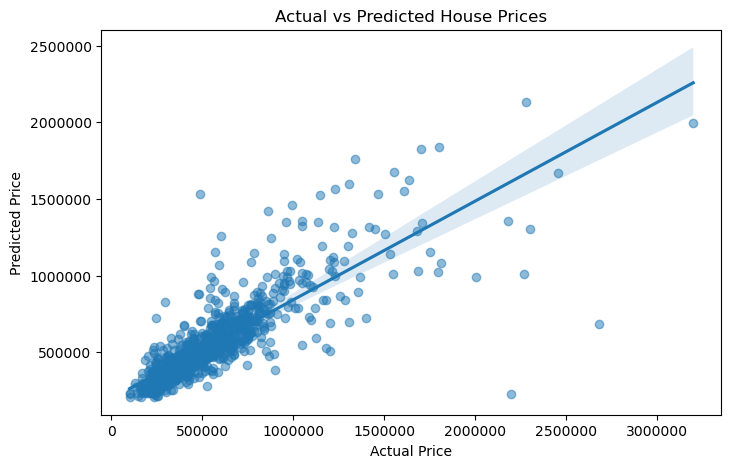

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.regplot(
    x=y_test,
    y=y_pred,
    scatter_kws={"alpha":0.5}
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.ticklabel_format(style="plain", axis="both")

plt.show()

In [88]:
X.columns

Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated', 'street', 'city', 'statezip', 'country'],
      dtype='str')

#                                     **THE END**
---